In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.gridspec as gridspec

from scipy.stats import norm as sp_norm
from scipy.optimize import differential_evolution
from scipy.special import rel_entr

In [147]:
# Read only the column names (first row)
data2023 = pd.read_csv(fr"atusact-2023/atusact_2023.dat", dtype={'TRCODE': str, 'TUCASEID': str})
respondents2023 = pd.read_csv(fr"atusresp-2023/atusresp_2023.dat", dtype={'TUCASEID': str})
jointed_data2023 = pd.merge(data2023, respondents2023, on='TUCASEID', how='inner')
data2024 = pd.read_csv(fr"atusact-2024/atusact_2024.dat", dtype={'TRCODE': str, 'TUCASEID': str})
respondents2024 = pd.read_csv(fr"atusresp-2024/atusresp_2024.dat", dtype={'TUCASEID': str})
joined_data2024 = pd.merge(data2024, respondents2024, on='TUCASEID', how='inner')
joined_data = pd.concat([jointed_data2023, joined_data2024], ignore_index=True)

keep_cols = [
    'TUCASEID',
    'TUDIARYDAY',   # day of week (1=Sun, 2=Mon, ..., 7=Sat) — needed for daytype
    'TUFINLWGT',    # final person weight — use for nationally representative estimates
    'TESCHENR',
    'TESCHFT',
    'TESCHLVL',
    'TRHHCHILD',
    'TRDPFTPT',
    'TELFS',
    'TRTHH',
    'TRCODE',
    'TUACTDUR',   
    'TUSTARTTIM',
    'TUSTOPTIME',
    'TEWHERE',
]
joined_data = joined_data[[c for c in keep_cols if c in joined_data.columns]]

In [148]:
# TUDIARYDAY: 1=Sun, 2=Mon, 3=Tue, 4=Wed, 5=Thu, 6=Fri, 7=Sat
joined_data['daytype'] = joined_data['TUDIARYDAY'].map(
    lambda d: 'weekend' if d in (1, 7) else 'weekday'
)

In [149]:
# ── 1b. Compute time fields (diary starts at 4:00 AM) ────────────────────────
DIARY_START_MIN = 4 * 60  # 240 min

joined_data['t_start_min'] = pd.to_timedelta(joined_data['TUSTARTTIM']).dt.total_seconds() / 60
joined_data['t_entry'] = (joined_data['t_start_min'] - DIARY_START_MIN) % (24 * 60)
joined_data = joined_data.sort_values(['TUCASEID', 'TUDIARYDAY', 't_entry']).reset_index(drop=True)
joined_data['t_exit'] = joined_data['t_entry'] + joined_data['TUACTDUR']


# ── 2a. Classify each activity row ───────────────────────────────────────────
def classify_activity(row):
    if str(row['TRCODE']).startswith('01'):
        return 'sleep'
    elif row.get('TEWHERE', -1) == 1:
        return 'home'
    else:
        return 'away'

joined_data['category'] = joined_data.apply(classify_activity, axis=1)

## Step 1 — Filter: full-time away workers

Keep person-days where:
1. Person is **employed full-time** (`TELFS==1`, `TRDPFTPT==1`)
2. Weekday diary days where **all work episodes were at the office** (not at home)

In [150]:
# ── 1a. Filter to full-time employed ─────────────────────────────────────────
# TELFS==1: employed (at work or absent), TRDPFTPT==1: full-time
df = joined_data[
    (joined_data['TELFS'] == 1) &
    (joined_data['TRDPFTPT'] == 1)
].copy()

print(f"Full-time employed activity rows: {len(df):,}")
print(f"Unique respondents: {df['TUCASEID'].nunique():,}")

Full-time employed activity rows: 127,178
Unique respondents: 7,212


In [151]:
# ── 1c. Classify weekday work location per person-day ────────────────────────
# Work episodes: TRCODE starts with '05'
# TEWHERE==1 → at respondent's home, anything else → away (office/other)

work_eps = df[df['TRCODE'].str.startswith('05') & (df['daytype'] == 'weekday')].copy()

day_work = (
    work_eps.groupby(['TUCASEID', 'TUDIARYDAY'])
    .agg(
        total_work_eps   = ('TEWHERE', 'count'),
        work_at_home_eps = ('TEWHERE', lambda x: (x == 1).sum()),
    )
    .reset_index()
)
day_work['pct_home'] = day_work['work_at_home_eps'] / day_work['total_work_eps']
day_work['work_location'] = day_work['pct_home'].map(
    lambda p: 'wfh' if p == 1.0 else ('office' if p == 0.0 else 'hybrid')
)

df = df.merge(
    day_work[['TUCASEID', 'TUDIARYDAY', 'work_location']],
    on=['TUCASEID', 'TUDIARYDAY'], how='left'
)
# Weekends and days with no work episodes → 'no_work'
df['work_location'] = df['work_location'].fillna('no_work')

print("Weekday work-location breakdown (activity rows):")
print(df[df['daytype'] == 'weekday']['work_location'].value_counts())
print(df[df['daytype'] == 'weekday']['work_location'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Weekday work-location breakdown (activity rows):
work_location
office     37018
wfh        13741
hybrid      8413
no_work     7590
Name: count, dtype: int64
work_location
office     55.4%
wfh        20.6%
hybrid     12.6%
no_work    11.4%
Name: proportion, dtype: object


In [152]:
# ── 1d. Keep weekday office days + all weekend days ──────────────────────────
day_away = df[
    ((df['daytype'] == 'weekday') & (df['work_location'] == 'office')) |
    (df['daytype'] == 'weekend')
].reset_index(drop=True)

print(f"After office-day filter:")
print(f"  Weekday activity rows : {len(day_away[day_away['daytype']=='weekday']):,}")
print(f"  Weekend activity rows : {len(day_away[day_away['daytype']=='weekend']):,}")
print(f"  Unique respondents    : {day_away['TUCASEID'].nunique():,}")

After office-day filter:
  Weekday activity rows : 37,018
  Weekend activity rows : 60,416
  Unique respondents    : 5,575


## Leave Home

Computing weekday distribution...
Computing weekend distribution...


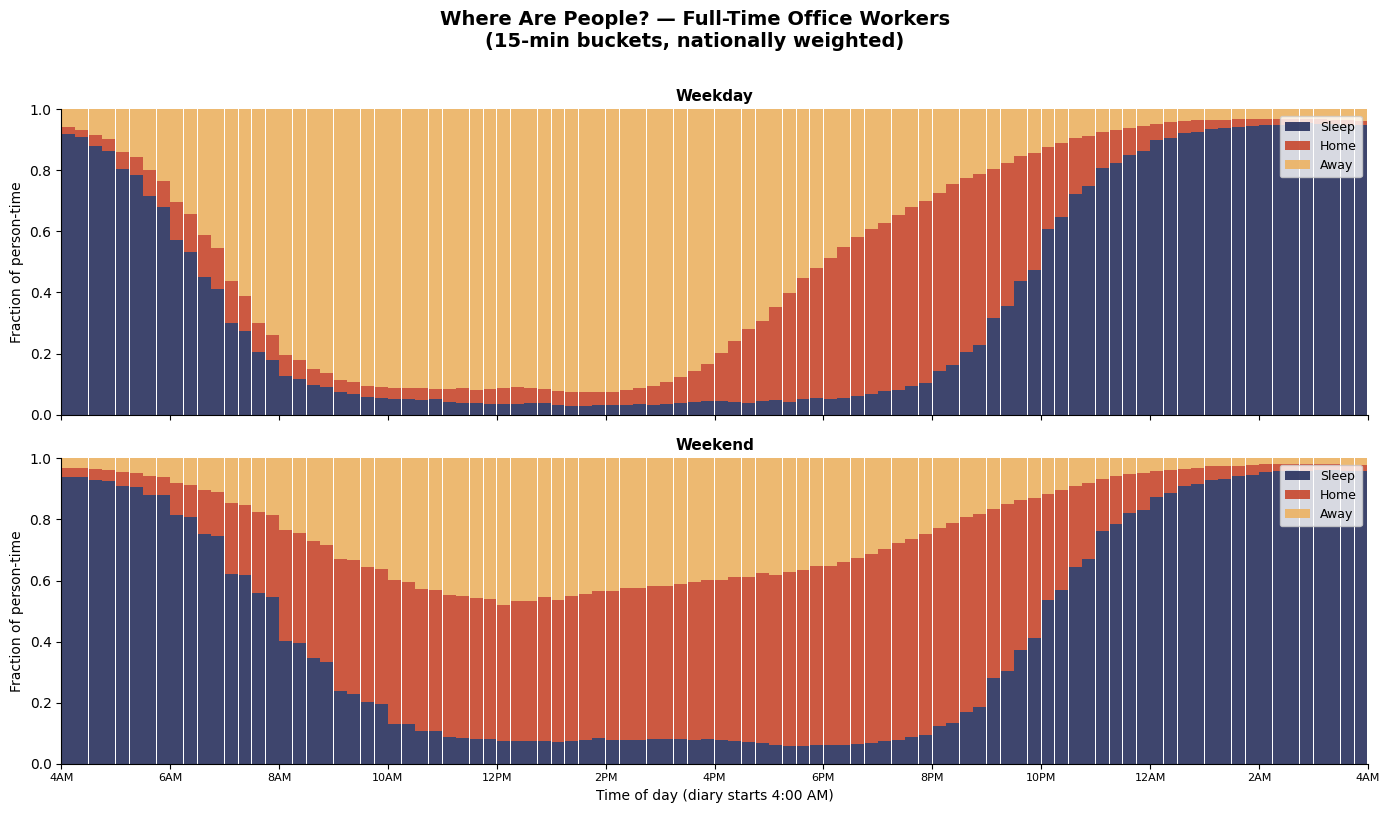

In [153]:
# %%
# ── Step 2: Weighted person-time visualization ────────────────────────────────
# Categories: 'away' (TRCODE starts with '18' = traveling, or any non-home non-sleep)
# Actually: we classify by TEWHERE location field:
#   TEWHERE==1 → 'home'
#   TEWHERE==3 → 'workplace/away'
#   TRCODE starts with '01' → 'sleep'


# ── 2b. Build 15-min time buckets (0..95) covering 4am to 4am next day ───────
# t_entry and t_exit are in minutes since 4am
BUCKET_MINUTES = 15
N_BUCKETS = 96   # 24*60 / 15
bucket_edges = np.arange(0, N_BUCKETS + 1) * BUCKET_MINUTES  # 0, 15, 30, ..., 1440

# ── 2c. For each activity, distribute weighted minutes into buckets ───────────
# Weight = TUFINLWGT (person weight for national representativeness)

def compute_weighted_distribution(df_subset):
    """
    Returns array of shape (3, 96): [sleep, home, away] x 96 buckets
    Values = sum of weighted person-minutes in each bucket
    """
    cats = ['sleep', 'home', 'away']
    result = {c: np.zeros(N_BUCKETS) for c in cats}

    for _, row in df_subset.iterrows():
        t_start = row['t_entry']
        t_end   = row['t_exit']
        weight  = row.get('TUFINLWGT', 1.0)
        cat     = row['category']

        # Clip to diary window
        t_start = max(0, min(t_start, N_BUCKETS * BUCKET_MINUTES))
        t_end   = max(0, min(t_end,   N_BUCKETS * BUCKET_MINUTES))
        if t_end <= t_start:
            continue

        # Find overlapping buckets
        b_start = int(t_start // BUCKET_MINUTES)
        b_end   = int(np.ceil(t_end / BUCKET_MINUTES))
        b_end   = min(b_end, N_BUCKETS)

        for b in range(b_start, b_end):
            bucket_s = b * BUCKET_MINUTES
            bucket_e = bucket_s + BUCKET_MINUTES
            overlap  = min(t_end, bucket_e) - max(t_start, bucket_s)
            if overlap > 0:
                result[cat][b] += weight * overlap

    return result

print("Computing weekday distribution...")
wd_dist = compute_weighted_distribution(day_away[day_away['daytype'] == 'weekday'])

print("Computing weekend distribution...")
we_dist = compute_weighted_distribution(day_away[day_away['daytype'] == 'weekend'])

# ── 2d. Normalize to fractions (sum across categories = 1 per bucket) ─────────
def normalize_dist(dist):
    cats = ['sleep', 'home', 'away']
    total = sum(dist[c] for c in cats)
    total = np.where(total == 0, 1, total)  # avoid div/0
    return {c: dist[c] / total for c in cats}

wd_norm = normalize_dist(wd_dist)
we_norm = normalize_dist(we_dist)

# ── 2e. Plot ──────────────────────────────────────────────────────────────────
bucket_centers = (np.arange(N_BUCKETS) + 0.5) * BUCKET_MINUTES  # minutes since 4am

# Convert to clock hours for x-axis: 4am + minutes
def min_to_label(m):
    total_min = int(4 * 60 + m) % (24 * 60)
    h, mn = divmod(total_min, 60)
    suffix = 'AM' if h < 12 else 'PM'
    h12 = h % 12 or 12
    return f"{h12}{'AM' if h<12 else 'PM'}" if mn == 0 else f"{h12}:{mn:02d}"

xtick_positions = np.arange(0, N_BUCKETS * BUCKET_MINUTES + 1, 2 * 60)  # every 2 hours
xtick_labels = [min_to_label(m) for m in xtick_positions]

colors = {
    'sleep': '#2d3561',
    'home':  '#c84b31',
    'away':  '#ecb365',
}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Where Are People? — Full-Time Office Workers\n(15-min buckets, nationally weighted)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (label, norm_dist) in zip(axes, [('Weekday', wd_norm), ('Weekend', we_norm)]):
    cats = ['sleep', 'home', 'away']
    stack = np.array([norm_dist[c] for c in cats])

    bottom = np.zeros(N_BUCKETS)
    for i, cat in enumerate(cats):
        ax.bar(bucket_centers, stack[i], width=BUCKET_MINUTES * 0.95,
               bottom=bottom, color=colors[cat], label=cat.capitalize(), alpha=0.92)
        bottom += stack[i]

    ax.set_ylabel('Fraction of person-time', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
    ax.legend(loc='upper right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
plt.tight_layout()
plt.show()

## Day-Away Model

Two-stage model:
1. **Binomial**: `p` = probability the day is an "away day" at all
2. **Normal leave/return**: given away, leave ~ N(μ_l, σ_l) and return ~ N(μ_r, σ_r)

`P(away at t) = p · Φ((t − μ_l)/σ_l) · [1 − Φ((t − μ_r)/σ_r)]`

Fit 5 parameters `[p, μ_l, σ_l, μ_r, σ_r]` separately for weekday and weekend by minimizing KL divergence against observed away fractions.

In [154]:


# ── Model ─────────────────────────────────────────────────────────────────────
def model_binom_normal(p, mu_l, sig_l, mu_r, sig_r):
    """
    P(away at t) = p * Phi((t-mu_l)/sig_l) * (1 - Phi((t-mu_r)/sig_r))
    p    : probability the day is an away day at all  (binomial)
    mu_l, sig_l : leave-time Normal (minutes since 4am)
    mu_r, sig_r : return-time Normal (minutes since 4am)
    """
    p_left  = sp_norm.cdf(bucket_centers, mu_l, sig_l)
    p_right = 1 - sp_norm.cdf(bucket_centers, mu_r, sig_r)
    return p * p_left * p_right  # shape (96,)

# ── KL divergence loss ────────────────────────────────────────────────────────
def kl_loss_binom(params, away_obs):
    p, mu_l, sig_l, mu_r, sig_r = params
    pred = np.clip(model_binom_normal(p, mu_l, sig_l, mu_r, sig_r), 1e-9, 1 - 1e-9)
    obs  = np.clip(away_obs, 1e-9, 1 - 1e-9)
    # symmetric KL: KL(obs||pred) + KL(1-obs||1-pred)
    return np.sum(rel_entr(obs, pred) + rel_entr(1 - obs, 1 - pred))

# ── Bounds: [p, mu_leave, sig_leave, mu_return, sig_return] ───────────────────
bounds_binom = [
    (0.3, 1.0),     # p:        away-day probability
    (60,  480),     # mu_l:     leave time  4am–12pm (min since 4am)
    (10,  150),     # sig_l:    leave spread
    (480, 1200),    # mu_r:     return time 12pm–8pm
    (10,  150),     # sig_r:    return spread
]

wd_away_obs = wd_norm['away']
we_away_obs = we_norm['away']

print("Fitting weekday (binomial + Normal)...")
res_wd_bn = differential_evolution(
    lambda p: kl_loss_binom(p, wd_away_obs), bounds=bounds_binom, seed=42, polish=True
)
print(f"  KL loss = {res_wd_bn.fun:.4f}")

print("Fitting weekend (binomial + Normal)...")
res_we_bn = differential_evolution(
    lambda p: kl_loss_binom(p, we_away_obs), bounds=bounds_binom, seed=42, polish=True
)
print(f"  KL loss = {res_we_bn.fun:.4f}")

# ── Pretty-print results ──────────────────────────────────────────────────────
def fmt(m):
    t = int(4*60 + m) % (24*60)
    h, mn = divmod(t, 60)
    return f"{'12' if h%12==0 else h%12}:{mn:02d}{'AM' if h<12 else 'PM'}"

print("\n── Fitted parameters ──────────────────────────────────────────────────")
for label, res in [('Weekday', res_wd_bn), ('Weekend', res_we_bn)]:
    p, mu_l, sig_l, mu_r, sig_r = res.x
    print(f"{label}:")
    print(f"  p (away-day prob) = {p:.3f}")
    print(f"  Leave  : {fmt(mu_l)}  ± {sig_l/60:.1f}h")
    print(f"  Return : {fmt(mu_r)}  ± {sig_r/60:.1f}h")
    print(f"  Duration (mean) : {(mu_r - mu_l)/60:.1f}h")
    print()

# ── Compare KL losses across all three models ─────────────────────────────────
print("── KL loss comparison ─────────────────────────────────────────────────")
print(f"{'Model':<28} {'Weekday':>10} {'Weekend':>10}")
print(f"{'Binomial + Normal':<28} {res_wd_bn.fun:>10.4f} {res_we_bn.fun:>10.4f}")

Fitting weekday (binomial + Normal)...
  KL loss = 1.3525
Fitting weekend (binomial + Normal)...
  KL loss = 0.3200

── Fitted parameters ──────────────────────────────────────────────────
Weekday:
  p (away-day prob) = 0.917
  Leave  : 6:41AM  ± 1.4h
  Return : 7:08PM  ± 2.5h
  Duration (mean) : 12.5h

Weekend:
  p (away-day prob) = 0.428
  Leave  : 7:51AM  ± 2.0h
  Return : 8:49PM  ± 2.5h
  Duration (mean) : 13.0h

── KL loss comparison ─────────────────────────────────────────────────
Model                           Weekday    Weekend
Binomial + Normal                1.3525     0.3200


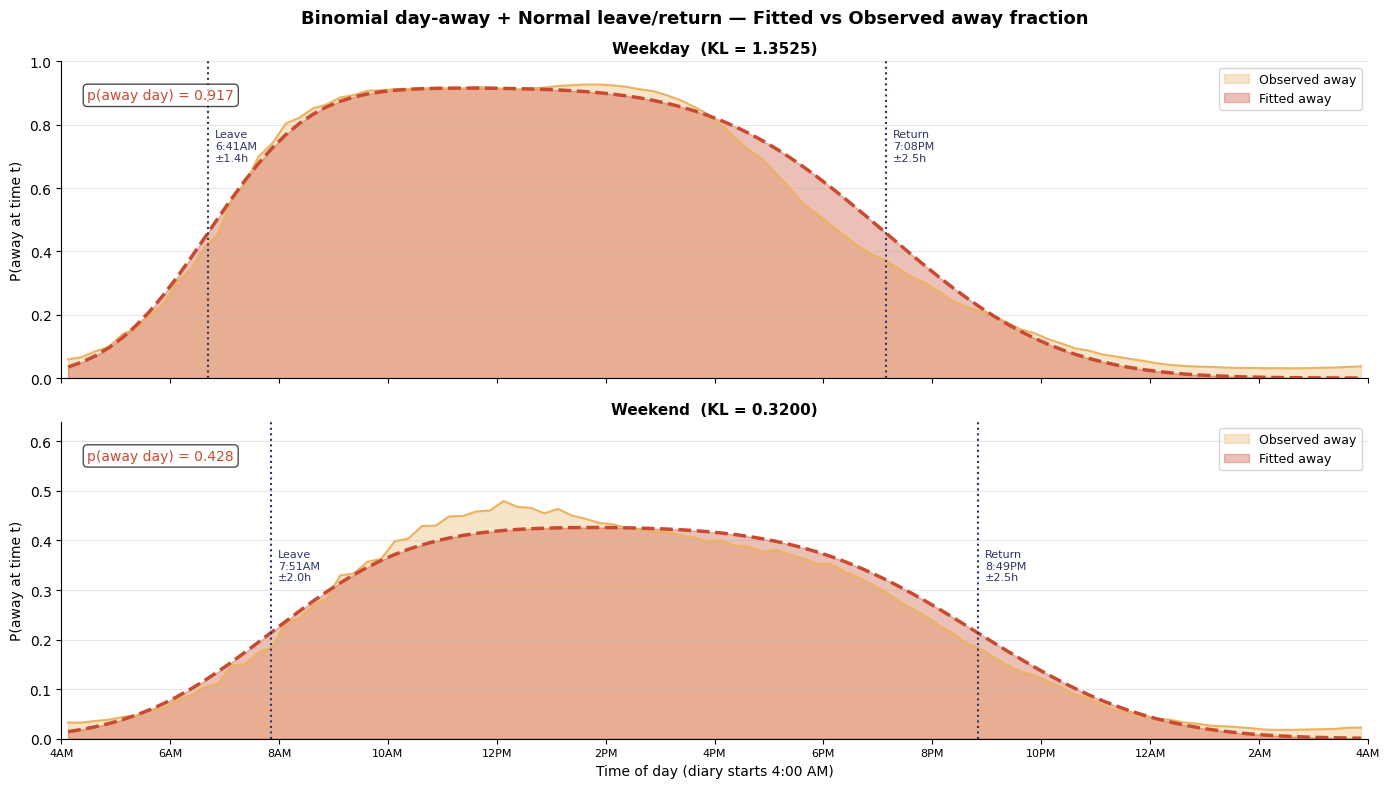

In [156]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    'Binomial day-away + Normal leave/return — Fitted vs Observed away fraction',
    fontsize=13, fontweight='bold'
)

for ax, (label, away_obs, res) in zip(axes, [
    ('Weekday', wd_away_obs, res_wd_bn),
    ('Weekend', we_away_obs, res_we_bn),
]):
    p, mu_l, sig_l, mu_r, sig_r = res.x
    away_pred = model_binom_normal(p, mu_l, sig_l, mu_r, sig_r)

    ax.fill_between(bucket_centers, away_obs,  alpha=0.35, color='#ecb365', label='Observed away')
    ax.fill_between(bucket_centers, away_pred, alpha=0.35, color='#c84b31', label='Fitted away')
    ax.plot(bucket_centers, away_obs,  color='#ecb365', lw=1.5)
    ax.plot(bucket_centers, away_pred, color='#c84b31', lw=2.5, ls='--')

    # Mark leave / return means
    ax.axvline(mu_l, color='#2d3561', lw=1.5, ls=':')
    ax.axvline(mu_r, color='#2d3561', lw=1.5, ls=':')
    ax.text(mu_l + 8, away_pred.max() * 0.75,
            f'Leave\n{fmt(mu_l)}\n±{sig_l/60:.1f}h', fontsize=8, color='#2d3561')
    ax.text(mu_r + 8, away_pred.max() * 0.75,
            f'Return\n{fmt(mu_r)}\n±{sig_r/60:.1f}h', fontsize=8, color='#2d3561')

    # Annotate p
    ax.text(0.02, 0.88,
            f'p(away day) = {p:.3f}',
            transform=ax.transAxes, fontsize=10, color='#c84b31',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_ylim(0, min(1, away_pred.max() * 1.5))
    ax.set_ylabel('P(away at time t)', fontsize=10)
    ax.set_title(f'{label}  (KL = {res.fun:.4f})', fontsize=11, fontweight='bold')
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
plt.tight_layout()
plt.savefig('binom_normal_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## WFH

In [157]:
# ── 1d. Keep weekday office days + all weekend days ──────────────────────────
day_home = df[
    ((df['daytype'] == 'weekday') & (df['work_location'] != 'office')) 
].reset_index(drop=True)

print(f"After office-day filter:")
print(f"  Weekday activity rows : {len(day_home[day_home['daytype']=='weekday']):,}")
print(f"  Unique respondents    : {day_home['TUCASEID'].nunique():,}")

After office-day filter:
  Weekday activity rows : 29,744
  Unique respondents    : 1,637


Computing weekday distribution...


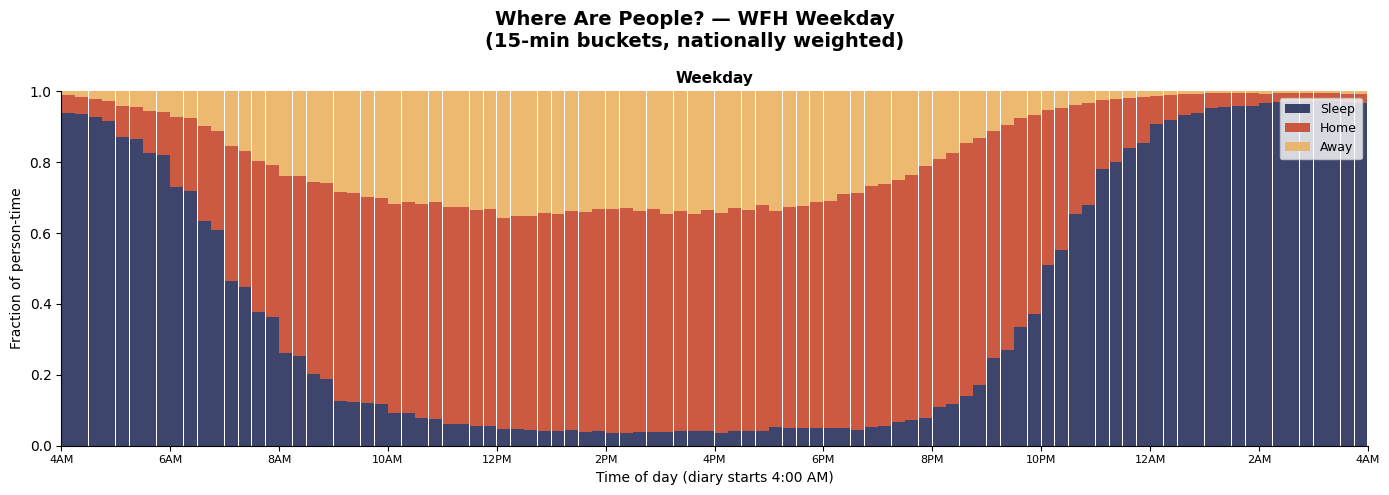

In [158]:
# %%
# ── Step 2: Weighted person-time visualization ────────────────────────────────

BUCKET_MINUTES = 15
N_BUCKETS = 96
bucket_edges = np.arange(0, N_BUCKETS + 1) * BUCKET_MINUTES

def compute_weighted_distribution(df_subset):
    cats = ['sleep', 'home', 'away']
    result = {c: np.zeros(N_BUCKETS) for c in cats}
    for _, row in df_subset.iterrows():
        t_start = row['t_entry']
        t_end   = row['t_exit']
        weight  = row.get('TUFINLWGT', 1.0)
        cat     = row['category']
        t_start = max(0, min(t_start, N_BUCKETS * BUCKET_MINUTES))
        t_end   = max(0, min(t_end,   N_BUCKETS * BUCKET_MINUTES))
        if t_end <= t_start:
            continue
        b_start = int(t_start // BUCKET_MINUTES)
        b_end   = min(int(np.ceil(t_end / BUCKET_MINUTES)), N_BUCKETS)
        for b in range(b_start, b_end):
            bucket_s = b * BUCKET_MINUTES
            bucket_e = bucket_s + BUCKET_MINUTES
            overlap  = min(t_end, bucket_e) - max(t_start, bucket_s)
            if overlap > 0:
                result[cat][b] += weight * overlap
    return result

print("Computing weekday distribution...")
wd_dist = compute_weighted_distribution(day_home[day_home['daytype'] == 'weekday'])

def normalize_dist(dist):
    cats = ['sleep', 'home', 'away']
    total = sum(dist[c] for c in cats)
    total = np.where(total == 0, 1, total)
    return {c: dist[c] / total for c in cats}

wd_norm = normalize_dist(wd_dist)

bucket_centers = (np.arange(N_BUCKETS) + 0.5) * BUCKET_MINUTES

def min_to_label(m):
    total_min = int(4 * 60 + m) % (24 * 60)
    h, mn = divmod(total_min, 60)
    h12 = h % 12 or 12
    return f"{h12}{'AM' if h<12 else 'PM'}" if mn == 0 else f"{h12}:{mn:02d}"

xtick_positions = np.arange(0, N_BUCKETS * BUCKET_MINUTES + 1, 2 * 60)
xtick_labels = [min_to_label(m) for m in xtick_positions]

colors = {'sleep': '#2d3561', 'home': '#c84b31', 'away': '#ecb365'}

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Where Are People? — WFH Weekday\n(15-min buckets, nationally weighted)',
             fontsize=14, fontweight='bold')

cats = ['sleep', 'home', 'away']
bottom = np.zeros(N_BUCKETS)
for cat in cats:
    ax.bar(bucket_centers, wd_norm[cat], width=BUCKET_MINUTES * 0.95,
           bottom=bottom, color=colors[cat], label=cat.capitalize(), alpha=0.92)
    bottom += wd_norm[cat]

ax.set_ylabel('Fraction of person-time', fontsize=10)
ax.set_title('Weekday', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, fontsize=8)
ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
ax.set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [159]:

# ── Model ─────────────────────────────────────────────────────────────────────
def model_binom_normal(p, mu_l, sig_l, mu_r, sig_r):
    """
    P(away at t) = p * Phi((t-mu_l)/sig_l) * (1 - Phi((t-mu_r)/sig_r))
    p    : probability the day is an away day at all  (binomial)
    mu_l, sig_l : leave-time Normal (minutes since 4am)
    mu_r, sig_r : return-time Normal (minutes since 4am)
    """
    p_left  = sp_norm.cdf(bucket_centers, mu_l, sig_l)
    p_right = 1 - sp_norm.cdf(bucket_centers, mu_r, sig_r)
    return p * p_left * p_right  # shape (96,)

# ── KL divergence loss ────────────────────────────────────────────────────────
def kl_loss_binom(params, away_obs):
    p, mu_l, sig_l, mu_r, sig_r = params
    pred = np.clip(model_binom_normal(p, mu_l, sig_l, mu_r, sig_r), 1e-9, 1 - 1e-9)
    obs  = np.clip(away_obs, 1e-9, 1 - 1e-9)
    # symmetric KL: KL(obs||pred) + KL(1-obs||1-pred)
    return np.sum(rel_entr(obs, pred) + rel_entr(1 - obs, 1 - pred))

# ── Bounds: [p, mu_leave, sig_leave, mu_return, sig_return] ───────────────────
bounds_binom = [
    (0.1, 1.0),     # p:        away-day probability
    (60,  1000),     # mu_l:     leave time  4am–12pm (min since 4am)
    (10,  500),     # sig_l:    leave spread
    (480, 1200),    # mu_r:     return time 12pm–8pm
    (10,  500),     # sig_r:    return spread
]

wd_away_obs = wd_norm['away']

print("Fitting weekday (binomial + Normal)...")
res_wd_bn = differential_evolution(
    lambda p: kl_loss_binom(p, wd_away_obs), bounds=bounds_binom, seed=42, polish=True
)
print(f"  KL loss = {res_wd_bn.fun:.4f}")


# ── Pretty-print results ──────────────────────────────────────────────────────
def fmt(m):
    t = int(4*60 + m) % (24*60)
    h, mn = divmod(t, 60)
    return f"{'12' if h%12==0 else h%12}:{mn:02d}{'AM' if h<12 else 'PM'}"

print("\n── Fitted parameters ──────────────────────────────────────────────────")
label, res=('Weekday', res_wd_bn)
p, mu_l, sig_l, mu_r, sig_r = res.x
print(f"{label}:")
print(f"  p (away-day prob) = {p:.3f}")
print(f"  Leave  : {fmt(mu_l)}  ± {sig_l/60:.1f}h")
print(f"  Return : {fmt(mu_r)}  ± {sig_r/60:.1f}h")
print(f"  Duration (mean) : {(mu_r - mu_l)/60:.1f}h")
print()

# ── Compare KL losses across all three models ─────────────────────────────────
print("── KL loss comparison ─────────────────────────────────────────────────")
print(f"{'Model':<28} {'Weekday':>10} ")
print(f"{'Binomial + Normal':<28} {res_wd_bn.fun:>10.4f} ")

Fitting weekday (binomial + Normal)...
  KL loss = 0.1249

── Fitted parameters ──────────────────────────────────────────────────
Weekday:
  p (away-day prob) = 0.351
  Leave  : 7:35AM  ± 1.9h
  Return : 8:11PM  ± 2.4h
  Duration (mean) : 12.6h

── KL loss comparison ─────────────────────────────────────────────────
Model                           Weekday 
Binomial + Normal                0.1249 


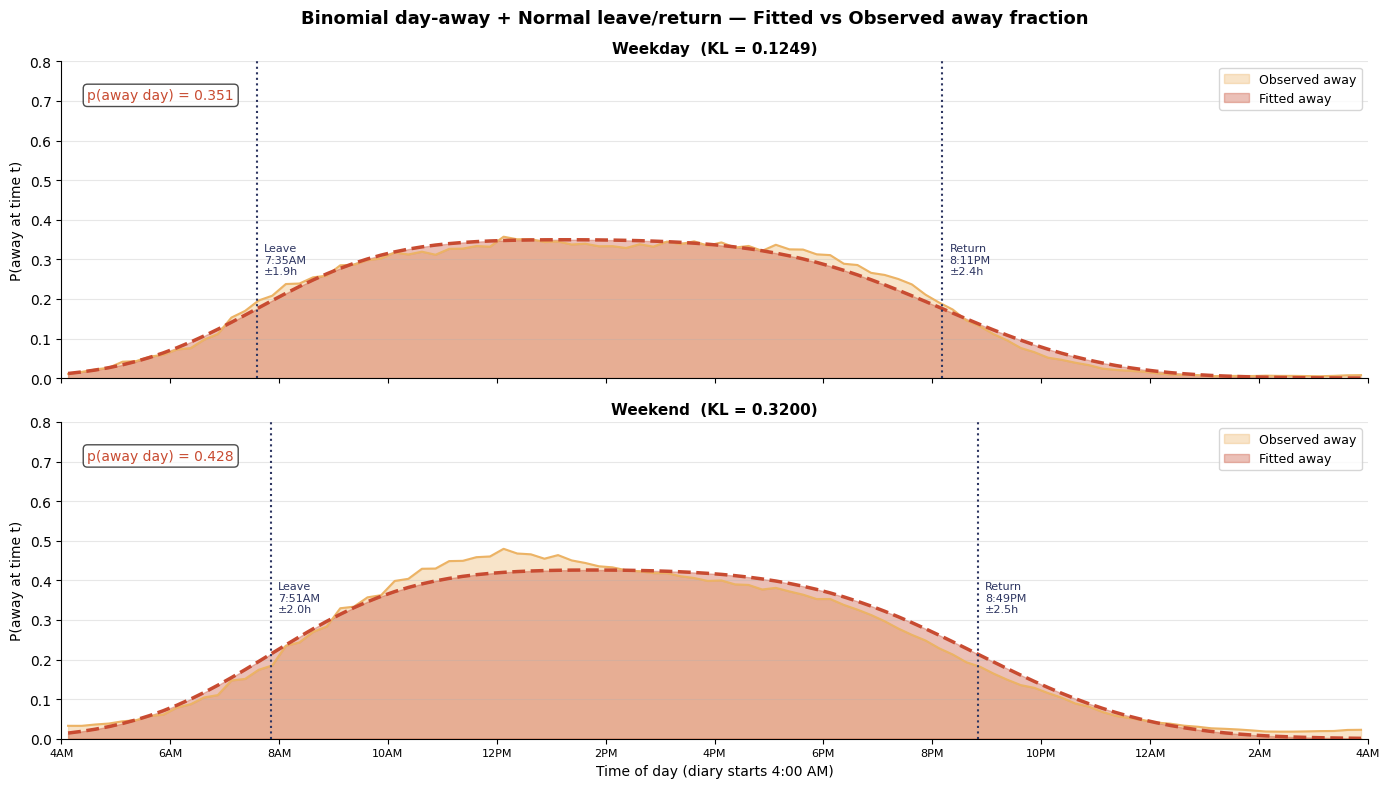

In [160]:
# ── Plot: Binomial+Normal fit vs observed ─────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    'Binomial day-away + Normal leave/return — Fitted vs Observed away fraction',
    fontsize=13, fontweight='bold'
)

for ax, (label, away_obs, res) in zip(axes, [
    ('Weekday', wd_away_obs, res_wd_bn),
    ('Weekend', we_away_obs, res_we_bn),
]):
    p, mu_l, sig_l, mu_r, sig_r = res.x
    away_pred = model_binom_normal(p, mu_l, sig_l, mu_r, sig_r)

    ax.fill_between(bucket_centers, away_obs,  alpha=0.35, color='#ecb365', label='Observed away')
    ax.fill_between(bucket_centers, away_pred, alpha=0.35, color='#c84b31', label='Fitted away')
    ax.plot(bucket_centers, away_obs,  color='#ecb365', lw=1.5)
    ax.plot(bucket_centers, away_pred, color='#c84b31', lw=2.5, ls='--')

    # Mark leave / return means
    ax.axvline(mu_l, color='#2d3561', lw=1.5, ls=':')
    ax.axvline(mu_r, color='#2d3561', lw=1.5, ls=':')
    ax.text(mu_l + 8, away_pred.max() * 0.75,
            f'Leave\n{fmt(mu_l)}\n±{sig_l/60:.1f}h', fontsize=8, color='#2d3561')
    ax.text(mu_r + 8, away_pred.max() * 0.75,
            f'Return\n{fmt(mu_r)}\n±{sig_r/60:.1f}h', fontsize=8, color='#2d3561')

    # Annotate p
    ax.text(0.02, 0.88,
            f'p(away day) = {p:.3f}',
            transform=ax.transAxes, fontsize=10, color='#c84b31',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_ylim(0, min(1, away_pred.max() * 1.5))
    ax.set_ylabel('P(away at time t)', fontsize=10)
    ax.set_title(f'{label}  (KL = {res.fun:.4f})', fontsize=11, fontweight='bold')
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
    ax.set_ylim(0,0.8)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
plt.tight_layout()
plt.savefig('binom_normal_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## 

## for part-time worker

In [138]:
df = joined_data[
    (joined_data['TELFS'] == 1) &
    (joined_data['TRDPFTPT'] == 2)
].copy()

print(f"Part-time employed activity rows: {len(df):,}")
print(f"Unique respondents: {df['TUCASEID'].nunique():,}")

Part-time employed activity rows: 33,417
Unique respondents: 1,763


Computing weekday distribution...


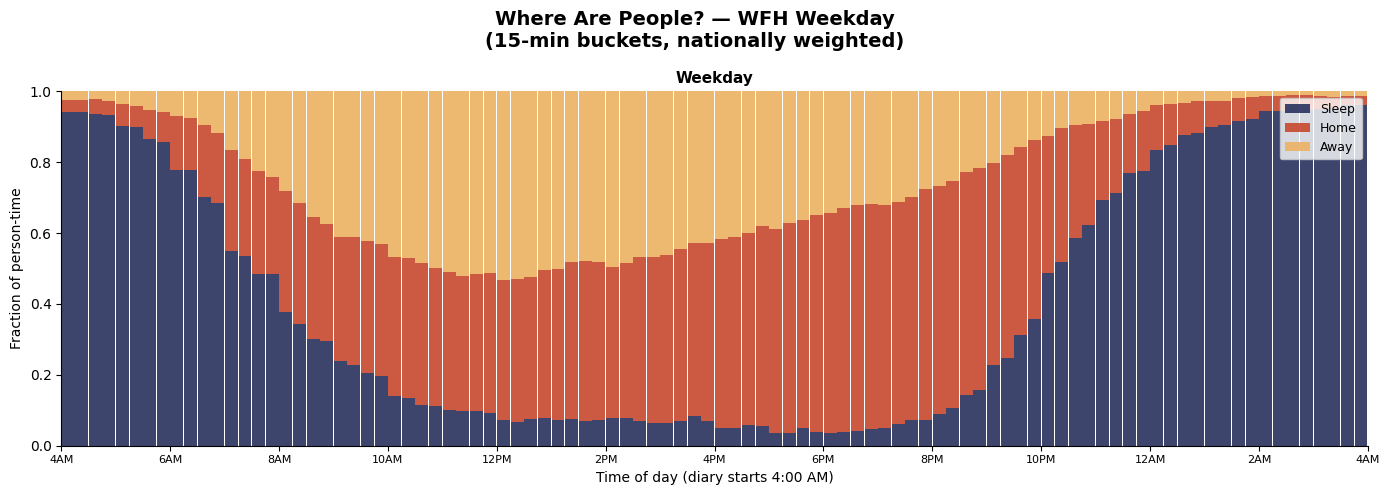

In [139]:
# %%
# ── Step 2: Weighted person-time visualization ────────────────────────────────

BUCKET_MINUTES = 15
N_BUCKETS = 96
bucket_edges = np.arange(0, N_BUCKETS + 1) * BUCKET_MINUTES

def compute_weighted_distribution(df_subset):
    cats = ['sleep', 'home', 'away']
    result = {c: np.zeros(N_BUCKETS) for c in cats}
    for _, row in df_subset.iterrows():
        t_start = row['t_entry']
        t_end   = row['t_exit']
        weight  = row.get('TUFINLWGT', 1.0)
        cat     = row['category']
        t_start = max(0, min(t_start, N_BUCKETS * BUCKET_MINUTES))
        t_end   = max(0, min(t_end,   N_BUCKETS * BUCKET_MINUTES))
        if t_end <= t_start:
            continue
        b_start = int(t_start // BUCKET_MINUTES)
        b_end   = min(int(np.ceil(t_end / BUCKET_MINUTES)), N_BUCKETS)
        for b in range(b_start, b_end):
            bucket_s = b * BUCKET_MINUTES
            bucket_e = bucket_s + BUCKET_MINUTES
            overlap  = min(t_end, bucket_e) - max(t_start, bucket_s)
            if overlap > 0:
                result[cat][b] += weight * overlap
    return result

print("Computing weekday distribution...")
wd_dist = compute_weighted_distribution(df[df['daytype'] == 'weekday'])

def normalize_dist(dist):
    cats = ['sleep', 'home', 'away']
    total = sum(dist[c] for c in cats)
    total = np.where(total == 0, 1, total)
    return {c: dist[c] / total for c in cats}

wd_norm = normalize_dist(wd_dist)

bucket_centers = (np.arange(N_BUCKETS) + 0.5) * BUCKET_MINUTES

def min_to_label(m):
    total_min = int(4 * 60 + m) % (24 * 60)
    h, mn = divmod(total_min, 60)
    h12 = h % 12 or 12
    return f"{h12}{'AM' if h<12 else 'PM'}" if mn == 0 else f"{h12}:{mn:02d}"

xtick_positions = np.arange(0, N_BUCKETS * BUCKET_MINUTES + 1, 2 * 60)
xtick_labels = [min_to_label(m) for m in xtick_positions]

colors = {'sleep': '#2d3561', 'home': '#c84b31', 'away': '#ecb365'}

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Where Are People? — WFH Weekday\n(15-min buckets, nationally weighted)',
             fontsize=14, fontweight='bold')

cats = ['sleep', 'home', 'away']
bottom = np.zeros(N_BUCKETS)
for cat in cats:
    ax.bar(bucket_centers, wd_norm[cat], width=BUCKET_MINUTES * 0.95,
           bottom=bottom, color=colors[cat], label=cat.capitalize(), alpha=0.92)
    bottom += wd_norm[cat]

ax.set_ylabel('Fraction of person-time', fontsize=10)
ax.set_title('Weekday', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels, fontsize=8)
ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
ax.set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
ax.legend(loc='upper right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## college

In [167]:
df = joined_data[
    (joined_data['TESCHLVL'] == 2) 
].copy()

print(f" activity rows: {len(df):,}")
print(f"Unique respondents: {df['TUCASEID'].nunique():,}")

 activity rows: 10,629
Unique respondents: 596


Computing weekday distribution...
Computing weekend distribution...


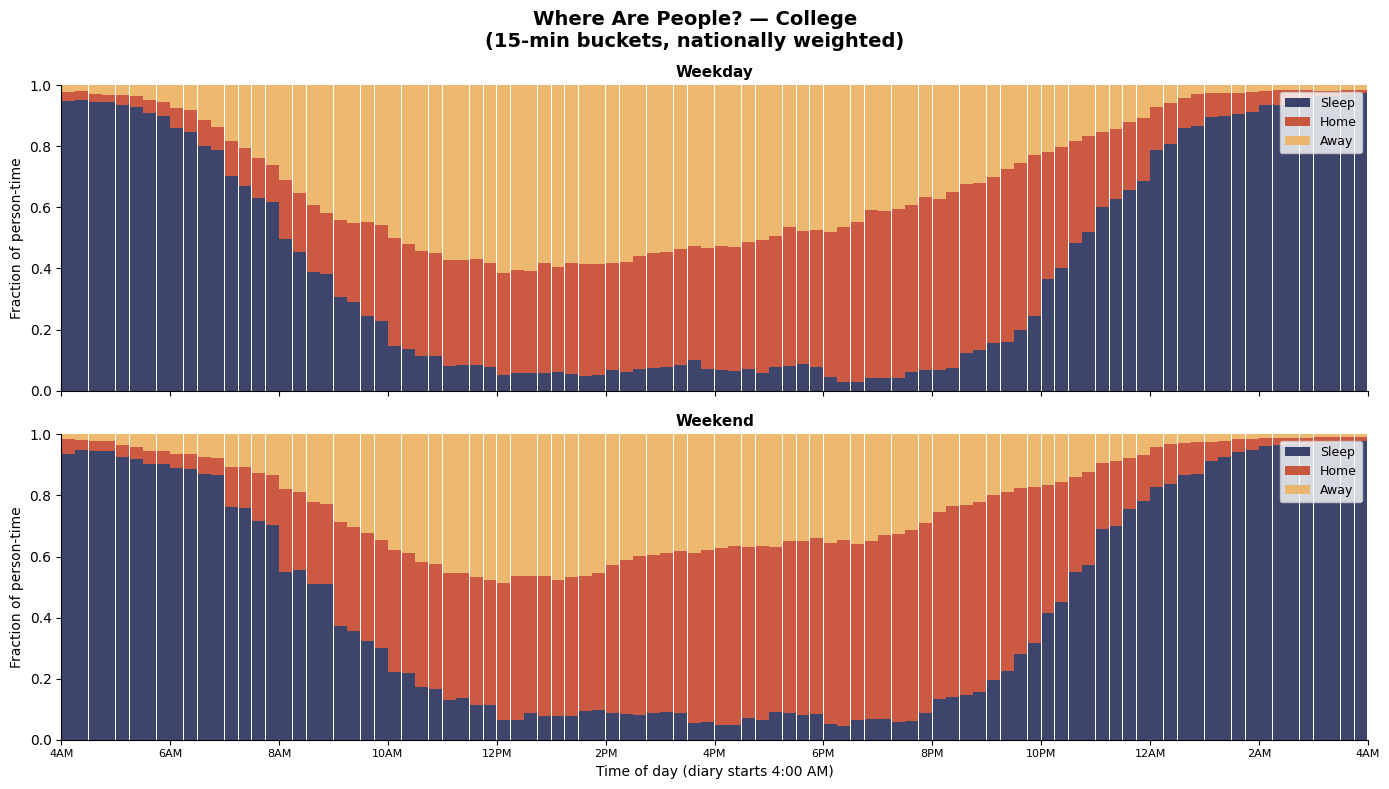

In [168]:
# %%
BUCKET_MINUTES = 15
N_BUCKETS = 96

def compute_weighted_distribution(df_subset):
    cats = ['sleep', 'home', 'away']
    result = {c: np.zeros(N_BUCKETS) for c in cats}
    for _, row in df_subset.iterrows():
        t_start = row['t_entry']
        t_end   = row['t_exit']
        weight  = row.get('TUFINLWGT', 1.0)
        cat     = row['category']
        t_start = max(0, min(t_start, N_BUCKETS * BUCKET_MINUTES))
        t_end   = max(0, min(t_end,   N_BUCKETS * BUCKET_MINUTES))
        if t_end <= t_start:
            continue
        b_start = int(t_start // BUCKET_MINUTES)
        b_end   = min(int(np.ceil(t_end / BUCKET_MINUTES)), N_BUCKETS)
        for b in range(b_start, b_end):
            bucket_s = b * BUCKET_MINUTES
            bucket_e = bucket_s + BUCKET_MINUTES
            overlap  = min(t_end, bucket_e) - max(t_start, bucket_s)
            if overlap > 0:
                result[cat][b] += weight * overlap
    return result

def normalize_dist(dist):
    cats = ['sleep', 'home', 'away']
    total = sum(dist[c] for c in cats)
    total = np.where(total == 0, 1, total)
    return {c: dist[c] / total for c in cats}

print("Computing weekday distribution...")
wd_norm = normalize_dist(compute_weighted_distribution(df[df['daytype'] == 'weekday']))
print("Computing weekend distribution...")
we_norm = normalize_dist(compute_weighted_distribution(df[df['daytype'] == 'weekend']))

bucket_centers = (np.arange(N_BUCKETS) + 0.5) * BUCKET_MINUTES

def min_to_label(m):
    total_min = int(4 * 60 + m) % (24 * 60)
    h, mn = divmod(total_min, 60)
    h12 = h % 12 or 12
    return f"{h12}{'AM' if h<12 else 'PM'}" if mn == 0 else f"{h12}:{mn:02d}"

xtick_positions = np.arange(0, N_BUCKETS * BUCKET_MINUTES + 1, 2 * 60)
xtick_labels    = [min_to_label(m) for m in xtick_positions]
colors = {'sleep': '#2d3561', 'home': '#c84b31', 'away': '#ecb365'}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Where Are People? — College\n(15-min buckets, nationally weighted)',
             fontsize=14, fontweight='bold')

for ax, (label, norm_dist) in zip(axes, [('Weekday', wd_norm), ('Weekend', we_norm)]):
    bottom = np.zeros(N_BUCKETS)
    for cat in ['sleep', 'home', 'away']:
        ax.bar(bucket_centers, norm_dist[cat], width=BUCKET_MINUTES * 0.95,
               bottom=bottom, color=colors[cat], label=cat.capitalize(), alpha=0.92)
        bottom += norm_dist[cat]
    ax.set_ylabel('Fraction of person-time', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
    ax.legend(loc='upper right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
plt.tight_layout()
plt.show()

In [169]:


# ── Model ─────────────────────────────────────────────────────────────────────
def model_binom_normal(p, mu_l, sig_l, mu_r, sig_r):
    """
    P(away at t) = p * Phi((t-mu_l)/sig_l) * (1 - Phi((t-mu_r)/sig_r))
    p    : probability the day is an away day at all  (binomial)
    mu_l, sig_l : leave-time Normal (minutes since 4am)
    mu_r, sig_r : return-time Normal (minutes since 4am)
    """
    p_left  = sp_norm.cdf(bucket_centers, mu_l, sig_l)
    p_right = 1 - sp_norm.cdf(bucket_centers, mu_r, sig_r)
    return p * p_left * p_right  # shape (96,)

# ── KL divergence loss ────────────────────────────────────────────────────────
def kl_loss_binom(params, away_obs):
    p, mu_l, sig_l, mu_r, sig_r = params
    pred = np.clip(model_binom_normal(p, mu_l, sig_l, mu_r, sig_r), 1e-9, 1 - 1e-9)
    obs  = np.clip(away_obs, 1e-9, 1 - 1e-9)
    # symmetric KL: KL(obs||pred) + KL(1-obs||1-pred)
    return np.sum(rel_entr(obs, pred) + rel_entr(1 - obs, 1 - pred))

# ── Bounds: [p, mu_leave, sig_leave, mu_return, sig_return] ───────────────────
bounds_binom = [
    (0.3, 1.0),     # p:        away-day probability
    (60,  800),     # mu_l:     leave time  4am–12pm (min since 4am)
    (10,  500),     # sig_l:    leave spread
    (480, 1200),    # mu_r:     return time 12pm–8pm
    (10,  500),     # sig_r:    return spread
]

wd_away_obs = wd_norm['away']
we_away_obs = we_norm['away']

print("Fitting weekday (binomial + Normal)...")
res_wd_bn = differential_evolution(
    lambda p: kl_loss_binom(p, wd_away_obs), bounds=bounds_binom, seed=42, polish=True
)
print(f"  KL loss = {res_wd_bn.fun:.4f}")

print("Fitting weekend (binomial + Normal)...")
res_we_bn = differential_evolution(
    lambda p: kl_loss_binom(p, we_away_obs), bounds=bounds_binom, seed=42, polish=True
)
print(f"  KL loss = {res_we_bn.fun:.4f}")

# ── Pretty-print results ──────────────────────────────────────────────────────
def fmt(m):
    t = int(4*60 + m) % (24*60)
    h, mn = divmod(t, 60)
    return f"{'12' if h%12==0 else h%12}:{mn:02d}{'AM' if h<12 else 'PM'}"

print("\n── Fitted parameters ──────────────────────────────────────────────────")
for label, res in [('Weekday', res_wd_bn), ('Weekend', res_we_bn)]:
    p, mu_l, sig_l, mu_r, sig_r = res.x
    print(f"{label}:")
    print(f"  p (away-day prob) = {p:.3f}")
    print(f"  Leave  : {fmt(mu_l)}  ± {sig_l/60:.1f}h")
    print(f"  Return : {fmt(mu_r)}  ± {sig_r/60:.1f}h")
    print(f"  Duration (mean) : {(mu_r - mu_l)/60:.1f}h")
    print()

# ── Compare KL losses across all three models ─────────────────────────────────
print("── KL loss comparison ─────────────────────────────────────────────────")
print(f"{'Model':<28} {'Weekday':>10} {'Weekend':>10}")
print(f"{'Binomial + Normal':<28} {res_wd_bn.fun:>10.4f} {res_we_bn.fun:>10.4f}")

Fitting weekday (binomial + Normal)...
  KL loss = 0.1181
Fitting weekend (binomial + Normal)...
  KL loss = 0.1680

── Fitted parameters ──────────────────────────────────────────────────
Weekday:
  p (away-day prob) = 0.581
  Leave  : 8:02AM  ± 1.8h
  Return : 8:54PM  ± 3.1h
  Duration (mean) : 12.9h

Weekend:
  p (away-day prob) = 0.450
  Leave  : 8:28AM  ± 2.1h
  Return : 8:38PM  ± 3.1h
  Duration (mean) : 12.2h

── KL loss comparison ─────────────────────────────────────────────────
Model                           Weekday    Weekend
Binomial + Normal                0.1181     0.1680


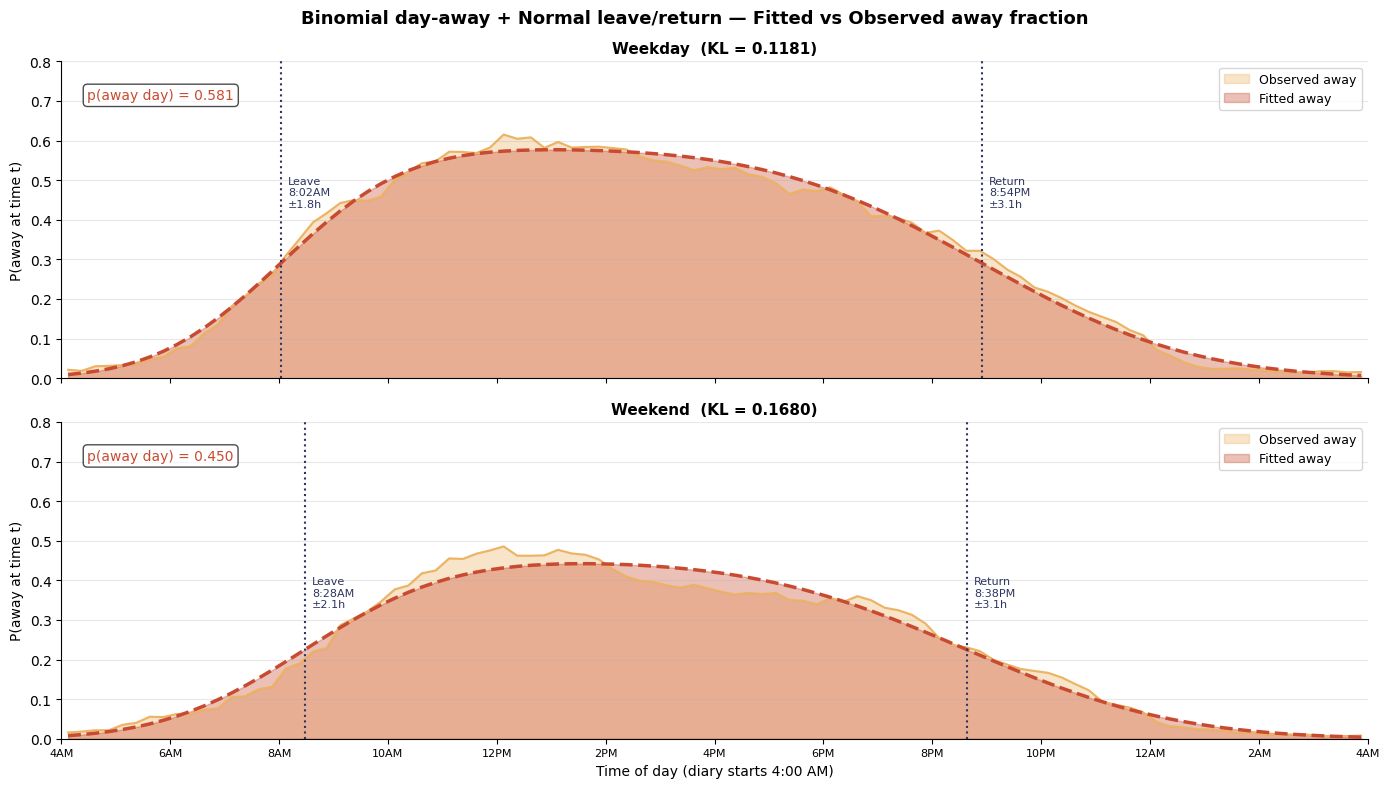

In [170]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    'Binomial day-away + Normal leave/return — Fitted vs Observed away fraction',
    fontsize=13, fontweight='bold'
)

for ax, (label, away_obs, res) in zip(axes, [
    ('Weekday', wd_away_obs, res_wd_bn),
    ('Weekend', we_away_obs, res_we_bn),
]):
    p, mu_l, sig_l, mu_r, sig_r = res.x
    away_pred = model_binom_normal(p, mu_l, sig_l, mu_r, sig_r)

    ax.fill_between(bucket_centers, away_obs,  alpha=0.35, color='#ecb365', label='Observed away')
    ax.fill_between(bucket_centers, away_pred, alpha=0.35, color='#c84b31', label='Fitted away')
    ax.plot(bucket_centers, away_obs,  color='#ecb365', lw=1.5)
    ax.plot(bucket_centers, away_pred, color='#c84b31', lw=2.5, ls='--')

    # Mark leave / return means
    ax.axvline(mu_l, color='#2d3561', lw=1.5, ls=':')
    ax.axvline(mu_r, color='#2d3561', lw=1.5, ls=':')
    ax.text(mu_l + 8, away_pred.max() * 0.75,
            f'Leave\n{fmt(mu_l)}\n±{sig_l/60:.1f}h', fontsize=8, color='#2d3561')
    ax.text(mu_r + 8, away_pred.max() * 0.75,
            f'Return\n{fmt(mu_r)}\n±{sig_r/60:.1f}h', fontsize=8, color='#2d3561')

    # Annotate p
    ax.text(0.02, 0.88,
            f'p(away day) = {p:.3f}',
            transform=ax.transAxes, fontsize=10, color='#c84b31',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_ylim(0, min(1, away_pred.max() * 1.5))
    ax.set_ylabel('P(away at time t)', fontsize=10)
    ax.set_title(f'{label}  (KL = {res.fun:.4f})', fontsize=11, fontweight='bold')
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
    ax.set_ylim(0,0.8)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
plt.tight_layout()
plt.savefig('binom_normal_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## HIGH SCHOOL

In [172]:
df = joined_data[
    (joined_data['TESCHLVL'] == 1) 
].copy()

print(f" activity rows: {len(df):,}")
print(f"Unique respondents: {df['TUCASEID'].nunique():,}")

 activity rows: 5,385
Unique respondents: 312


Computing weekday distribution...
Computing weekend distribution...


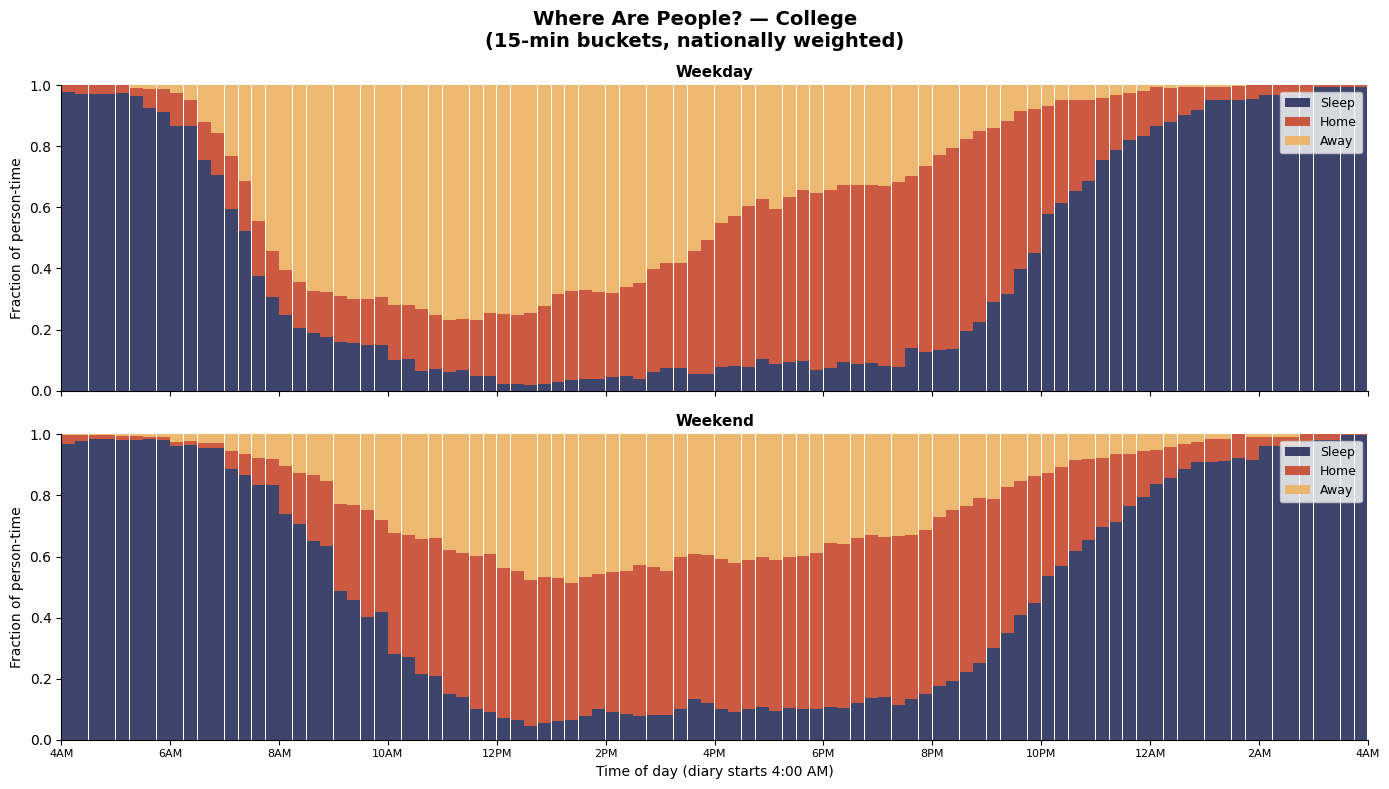

In [174]:
# %%
BUCKET_MINUTES = 15
N_BUCKETS = 96

def compute_weighted_distribution(df_subset):
    cats = ['sleep', 'home', 'away']
    result = {c: np.zeros(N_BUCKETS) for c in cats}
    for _, row in df_subset.iterrows():
        t_start = row['t_entry']
        t_end   = row['t_exit']
        weight  = row.get('TUFINLWGT', 1.0)
        cat     = row['category']
        t_start = max(0, min(t_start, N_BUCKETS * BUCKET_MINUTES))
        t_end   = max(0, min(t_end,   N_BUCKETS * BUCKET_MINUTES))
        if t_end <= t_start:
            continue
        b_start = int(t_start // BUCKET_MINUTES)
        b_end   = min(int(np.ceil(t_end / BUCKET_MINUTES)), N_BUCKETS)
        for b in range(b_start, b_end):
            bucket_s = b * BUCKET_MINUTES
            bucket_e = bucket_s + BUCKET_MINUTES
            overlap  = min(t_end, bucket_e) - max(t_start, bucket_s)
            if overlap > 0:
                result[cat][b] += weight * overlap
    return result

def normalize_dist(dist):
    cats = ['sleep', 'home', 'away']
    total = sum(dist[c] for c in cats)
    total = np.where(total == 0, 1, total)
    return {c: dist[c] / total for c in cats}

print("Computing weekday distribution...")
wd_norm = normalize_dist(compute_weighted_distribution(df[df['daytype'] == 'weekday']))
print("Computing weekend distribution...")
we_norm = normalize_dist(compute_weighted_distribution(df[df['daytype'] == 'weekend']))

bucket_centers = (np.arange(N_BUCKETS) + 0.5) * BUCKET_MINUTES

def min_to_label(m):
    total_min = int(4 * 60 + m) % (24 * 60)
    h, mn = divmod(total_min, 60)
    h12 = h % 12 or 12
    return f"{h12}{'AM' if h<12 else 'PM'}" if mn == 0 else f"{h12}:{mn:02d}"

xtick_positions = np.arange(0, N_BUCKETS * BUCKET_MINUTES + 1, 2 * 60)
xtick_labels    = [min_to_label(m) for m in xtick_positions]
colors = {'sleep': '#2d3561', 'home': '#c84b31', 'away': '#ecb365'}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Where Are People? — College\n(15-min buckets, nationally weighted)',
             fontsize=14, fontweight='bold')

for ax, (label, norm_dist) in zip(axes, [('Weekday', wd_norm), ('Weekend', we_norm)]):
    bottom = np.zeros(N_BUCKETS)
    for cat in ['sleep', 'home', 'away']:
        ax.bar(bucket_centers, norm_dist[cat], width=BUCKET_MINUTES * 0.95,
               bottom=bottom, color=colors[cat], label=cat.capitalize(), alpha=0.92)
        bottom += norm_dist[cat]
    ax.set_ylabel('Fraction of person-time', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
    ax.legend(loc='upper right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
plt.tight_layout()
plt.show()

In [175]:


# ── Model ─────────────────────────────────────────────────────────────────────
def model_binom_normal(p, mu_l, sig_l, mu_r, sig_r):
    """
    P(away at t) = p * Phi((t-mu_l)/sig_l) * (1 - Phi((t-mu_r)/sig_r))
    p    : probability the day is an away day at all  (binomial)
    mu_l, sig_l : leave-time Normal (minutes since 4am)
    mu_r, sig_r : return-time Normal (minutes since 4am)
    """
    p_left  = sp_norm.cdf(bucket_centers, mu_l, sig_l)
    p_right = 1 - sp_norm.cdf(bucket_centers, mu_r, sig_r)
    return p * p_left * p_right  # shape (96,)

# ── KL divergence loss ────────────────────────────────────────────────────────
def kl_loss_binom(params, away_obs):
    p, mu_l, sig_l, mu_r, sig_r = params
    pred = np.clip(model_binom_normal(p, mu_l, sig_l, mu_r, sig_r), 1e-9, 1 - 1e-9)
    obs  = np.clip(away_obs, 1e-9, 1 - 1e-9)
    # symmetric KL: KL(obs||pred) + KL(1-obs||1-pred)
    return np.sum(rel_entr(obs, pred) + rel_entr(1 - obs, 1 - pred))

# ── Bounds: [p, mu_leave, sig_leave, mu_return, sig_return] ───────────────────
bounds_binom = [
    (0.3, 1.0),     # p:        away-day probability
    (60,  800),     # mu_l:     leave time  4am–12pm (min since 4am)
    (10,  500),     # sig_l:    leave spread
    (480, 1200),    # mu_r:     return time 12pm–8pm
    (10,  500),     # sig_r:    return spread
]

wd_away_obs = wd_norm['away']
we_away_obs = we_norm['away']

print("Fitting weekday (binomial + Normal)...")
res_wd_bn = differential_evolution(
    lambda p: kl_loss_binom(p, wd_away_obs), bounds=bounds_binom, seed=42, polish=True
)
print(f"  KL loss = {res_wd_bn.fun:.4f}")

print("Fitting weekend (binomial + Normal)...")
res_we_bn = differential_evolution(
    lambda p: kl_loss_binom(p, we_away_obs), bounds=bounds_binom, seed=42, polish=True
)
print(f"  KL loss = {res_we_bn.fun:.4f}")

# ── Pretty-print results ──────────────────────────────────────────────────────
def fmt(m):
    t = int(4*60 + m) % (24*60)
    h, mn = divmod(t, 60)
    return f"{'12' if h%12==0 else h%12}:{mn:02d}{'AM' if h<12 else 'PM'}"

print("\n── Fitted parameters ──────────────────────────────────────────────────")
for label, res in [('Weekday', res_wd_bn), ('Weekend', res_we_bn)]:
    p, mu_l, sig_l, mu_r, sig_r = res.x
    print(f"{label}:")
    print(f"  p (away-day prob) = {p:.3f}")
    print(f"  Leave  : {fmt(mu_l)}  ± {sig_l/60:.1f}h")
    print(f"  Return : {fmt(mu_r)}  ± {sig_r/60:.1f}h")
    print(f"  Duration (mean) : {(mu_r - mu_l)/60:.1f}h")
    print()

# ── Compare KL losses across all three models ─────────────────────────────────
print("── KL loss comparison ─────────────────────────────────────────────────")
print(f"{'Model':<28} {'Weekday':>10} {'Weekend':>10}")
print(f"{'Binomial + Normal':<28} {res_wd_bn.fun:>10.4f} {res_we_bn.fun:>10.4f}")

Fitting weekday (binomial + Normal)...
  KL loss = 0.2644
Fitting weekend (binomial + Normal)...
  KL loss = 0.0874

── Fitted parameters ──────────────────────────────────────────────────
Weekday:
  p (away-day prob) = 0.742
  Leave  : 7:29AM  ± 0.8h
  Return : 5:53PM  ± 3.2h
  Duration (mean) : 10.4h

Weekend:
  p (away-day prob) = 0.448
  Leave  : 9:20AM  ± 1.8h
  Return : 8:42PM  ± 2.6h
  Duration (mean) : 11.4h

── KL loss comparison ─────────────────────────────────────────────────
Model                           Weekday    Weekend
Binomial + Normal                0.2644     0.0874


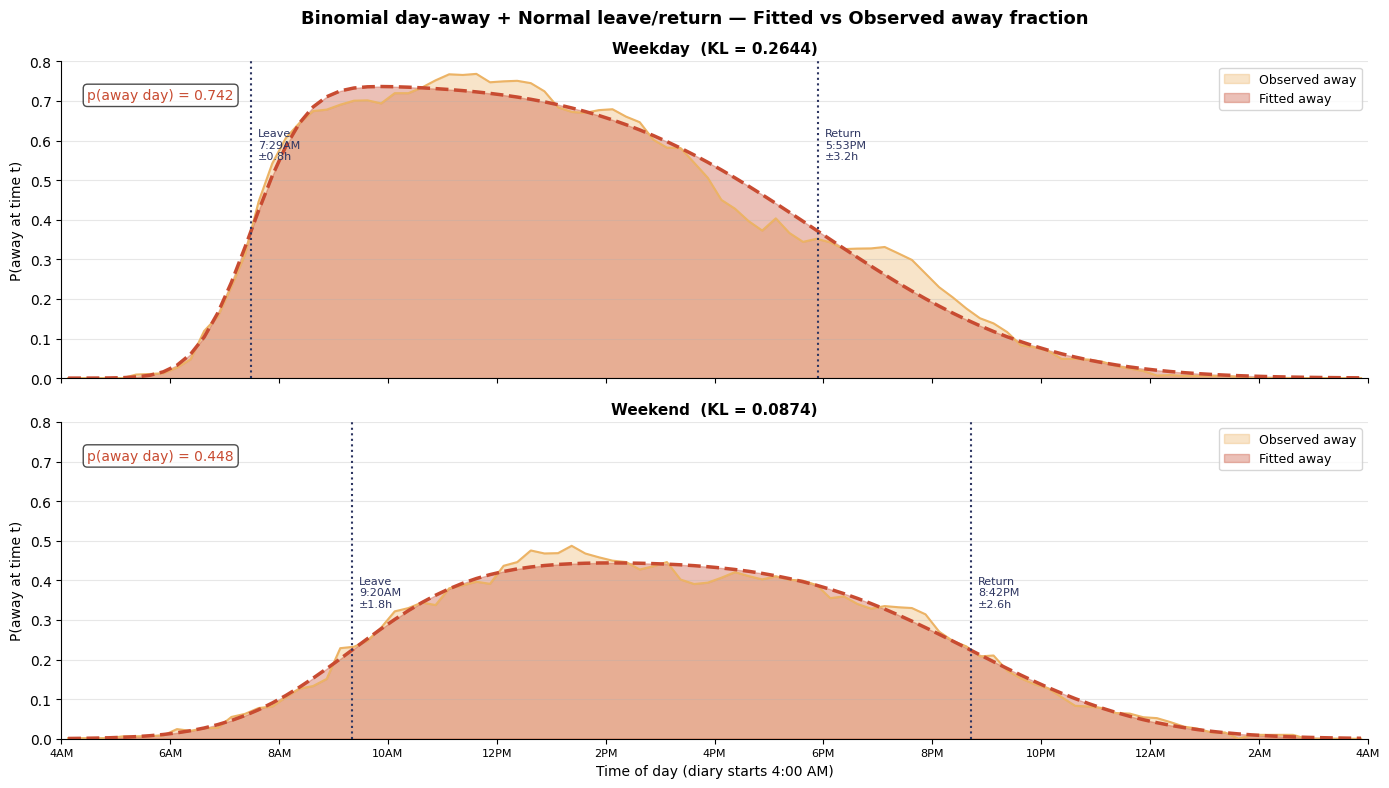

In [176]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    'Binomial day-away + Normal leave/return — Fitted vs Observed away fraction',
    fontsize=13, fontweight='bold'
)

for ax, (label, away_obs, res) in zip(axes, [
    ('Weekday', wd_away_obs, res_wd_bn),
    ('Weekend', we_away_obs, res_we_bn),
]):
    p, mu_l, sig_l, mu_r, sig_r = res.x
    away_pred = model_binom_normal(p, mu_l, sig_l, mu_r, sig_r)

    ax.fill_between(bucket_centers, away_obs,  alpha=0.35, color='#ecb365', label='Observed away')
    ax.fill_between(bucket_centers, away_pred, alpha=0.35, color='#c84b31', label='Fitted away')
    ax.plot(bucket_centers, away_obs,  color='#ecb365', lw=1.5)
    ax.plot(bucket_centers, away_pred, color='#c84b31', lw=2.5, ls='--')

    # Mark leave / return means
    ax.axvline(mu_l, color='#2d3561', lw=1.5, ls=':')
    ax.axvline(mu_r, color='#2d3561', lw=1.5, ls=':')
    ax.text(mu_l + 8, away_pred.max() * 0.75,
            f'Leave\n{fmt(mu_l)}\n±{sig_l/60:.1f}h', fontsize=8, color='#2d3561')
    ax.text(mu_r + 8, away_pred.max() * 0.75,
            f'Return\n{fmt(mu_r)}\n±{sig_r/60:.1f}h', fontsize=8, color='#2d3561')

    # Annotate p
    ax.text(0.02, 0.88,
            f'p(away day) = {p:.3f}',
            transform=ax.transAxes, fontsize=10, color='#c84b31',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_ylim(0, min(1, away_pred.max() * 1.5))
    ax.set_ylabel('P(away at time t)', fontsize=10)
    ax.set_title(f'{label}  (KL = {res.fun:.4f})', fontsize=11, fontweight='bold')
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
    ax.set_ylim(0,0.8)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
plt.tight_layout()
plt.savefig('binom_normal_fit.png', dpi=150, bbox_inches='tight')
plt.show()

In [177]:
df = joined_data[
    ~joined_data['TESCHLVL'].isin([1, 2]) &
    (joined_data['TELFS'] != 1)
].copy()

print(f" activity rows: {len(df):,}")
print(f"Unique respondents: {df['TUCASEID'].nunique():,}")

 activity rows: 124,753
Unique respondents: 6,822


Computing weekday distribution...
Computing weekend distribution...


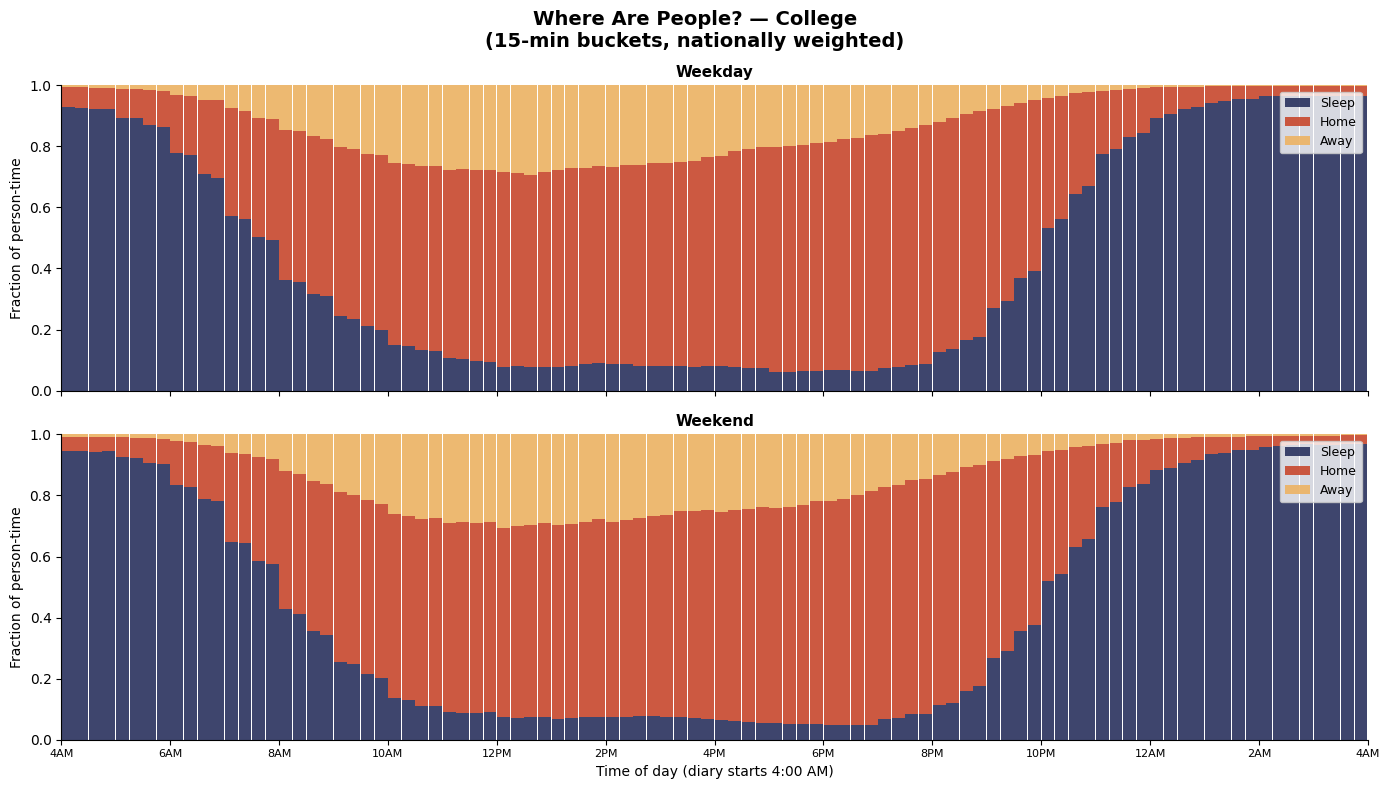

In [178]:
# %%
BUCKET_MINUTES = 15
N_BUCKETS = 96

def compute_weighted_distribution(df_subset):
    cats = ['sleep', 'home', 'away']
    result = {c: np.zeros(N_BUCKETS) for c in cats}
    for _, row in df_subset.iterrows():
        t_start = row['t_entry']
        t_end   = row['t_exit']
        weight  = row.get('TUFINLWGT', 1.0)
        cat     = row['category']
        t_start = max(0, min(t_start, N_BUCKETS * BUCKET_MINUTES))
        t_end   = max(0, min(t_end,   N_BUCKETS * BUCKET_MINUTES))
        if t_end <= t_start:
            continue
        b_start = int(t_start // BUCKET_MINUTES)
        b_end   = min(int(np.ceil(t_end / BUCKET_MINUTES)), N_BUCKETS)
        for b in range(b_start, b_end):
            bucket_s = b * BUCKET_MINUTES
            bucket_e = bucket_s + BUCKET_MINUTES
            overlap  = min(t_end, bucket_e) - max(t_start, bucket_s)
            if overlap > 0:
                result[cat][b] += weight * overlap
    return result

def normalize_dist(dist):
    cats = ['sleep', 'home', 'away']
    total = sum(dist[c] for c in cats)
    total = np.where(total == 0, 1, total)
    return {c: dist[c] / total for c in cats}

print("Computing weekday distribution...")
wd_norm = normalize_dist(compute_weighted_distribution(df[df['daytype'] == 'weekday']))
print("Computing weekend distribution...")
we_norm = normalize_dist(compute_weighted_distribution(df[df['daytype'] == 'weekend']))

bucket_centers = (np.arange(N_BUCKETS) + 0.5) * BUCKET_MINUTES

def min_to_label(m):
    total_min = int(4 * 60 + m) % (24 * 60)
    h, mn = divmod(total_min, 60)
    h12 = h % 12 or 12
    return f"{h12}{'AM' if h<12 else 'PM'}" if mn == 0 else f"{h12}:{mn:02d}"

xtick_positions = np.arange(0, N_BUCKETS * BUCKET_MINUTES + 1, 2 * 60)
xtick_labels    = [min_to_label(m) for m in xtick_positions]
colors = {'sleep': '#2d3561', 'home': '#c84b31', 'away': '#ecb365'}

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Where Are People? — College\n(15-min buckets, nationally weighted)',
             fontsize=14, fontweight='bold')

for ax, (label, norm_dist) in zip(axes, [('Weekday', wd_norm), ('Weekend', we_norm)]):
    bottom = np.zeros(N_BUCKETS)
    for cat in ['sleep', 'home', 'away']:
        ax.bar(bucket_centers, norm_dist[cat], width=BUCKET_MINUTES * 0.95,
               bottom=bottom, color=colors[cat], label=cat.capitalize(), alpha=0.92)
        bottom += norm_dist[cat]
    ax.set_ylabel('Fraction of person-time', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
    ax.legend(loc='upper right', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
plt.tight_layout()
plt.show()

In [180]:


# ── Model ─────────────────────────────────────────────────────────────────────
def model_binom_normal(p, mu_l, sig_l, mu_r, sig_r):
    """
    P(away at t) = p * Phi((t-mu_l)/sig_l) * (1 - Phi((t-mu_r)/sig_r))
    p    : probability the day is an away day at all  (binomial)
    mu_l, sig_l : leave-time Normal (minutes since 4am)
    mu_r, sig_r : return-time Normal (minutes since 4am)
    """
    p_left  = sp_norm.cdf(bucket_centers, mu_l, sig_l)
    p_right = 1 - sp_norm.cdf(bucket_centers, mu_r, sig_r)
    return p * p_left * p_right  # shape (96,)

# ── KL divergence loss ────────────────────────────────────────────────────────
def kl_loss_binom(params, away_obs):
    p, mu_l, sig_l, mu_r, sig_r = params
    pred = np.clip(model_binom_normal(p, mu_l, sig_l, mu_r, sig_r), 1e-9, 1 - 1e-9)
    obs  = np.clip(away_obs, 1e-9, 1 - 1e-9)
    # symmetric KL: KL(obs||pred) + KL(1-obs||1-pred)
    return np.sum(rel_entr(obs, pred) + rel_entr(1 - obs, 1 - pred))

# ── Bounds: [p, mu_leave, sig_leave, mu_return, sig_return] ───────────────────
bounds_binom = [
    (0.3, 1.0),     # p:        away-day probability
    (60,  800),     # mu_l:     leave time  4am–12pm (min since 4am)
    (10,  500),     # sig_l:    leave spread
    (480, 1200),    # mu_r:     return time 12pm–8pm
    (10,  500),     # sig_r:    return spread
]

wd_away_obs = wd_norm['away']
we_away_obs = we_norm['away']

print("Fitting weekday (binomial + Normal)...")
res_wd_bn = differential_evolution(
    lambda p: kl_loss_binom(p, wd_away_obs), bounds=bounds_binom, seed=42, polish=True
)
print(f"  KL loss = {res_wd_bn.fun:.4f}")

print("Fitting weekend (binomial + Normal)...")
res_we_bn = differential_evolution(
    lambda p: kl_loss_binom(p, we_away_obs), bounds=bounds_binom, seed=42, polish=True
)
print(f"  KL loss = {res_we_bn.fun:.4f}")

# ── Pretty-print results ──────────────────────────────────────────────────────
def fmt(m):
    t = int(4*60 + m) % (24*60)
    h, mn = divmod(t, 60)
    return f"{'12' if h%12==0 else h%12}:{mn:02d}{'AM' if h<12 else 'PM'}"

print("\n── Fitted parameters ──────────────────────────────────────────────────")
for label, res in [('Weekday', res_wd_bn), ('Weekend', res_we_bn)]:
    p, mu_l, sig_l, mu_r, sig_r = res.x
    print(f"{label}:")
    print(f"  p (away-day prob) = {p:.3f}")
    print(f"  Leave  : {fmt(mu_l)}  ± {sig_l/60:.1f}h")
    print(f"  Return : {fmt(mu_r)}  ± {sig_r/60:.1f}h")
    print(f"  Duration (mean) : {(mu_r - mu_l)/60:.1f}h")
    print()

# ── Compare KL losses across all three models ─────────────────────────────────
print("── KL loss comparison ─────────────────────────────────────────────────")
print(f"{'Model':<28} {'Weekday':>10} {'Weekend':>10}")
print(f"{'Binomial + Normal':<28} {res_wd_bn.fun:>10.4f} {res_we_bn.fun:>10.4f}")

Fitting weekday (binomial + Normal)...
  KL loss = 0.0473
Fitting weekend (binomial + Normal)...
  KL loss = 0.0411

── Fitted parameters ──────────────────────────────────────────────────
Weekday:
  p (away-day prob) = 0.300
  Leave  : 8:25AM  ± 1.8h
  Return : 6:51PM  ± 3.0h
  Duration (mean) : 10.4h

Weekend:
  p (away-day prob) = 0.302
  Leave  : 8:39AM  ± 1.8h
  Return : 7:29PM  ± 3.0h
  Duration (mean) : 10.8h

── KL loss comparison ─────────────────────────────────────────────────
Model                           Weekday    Weekend
Binomial + Normal                0.0473     0.0411


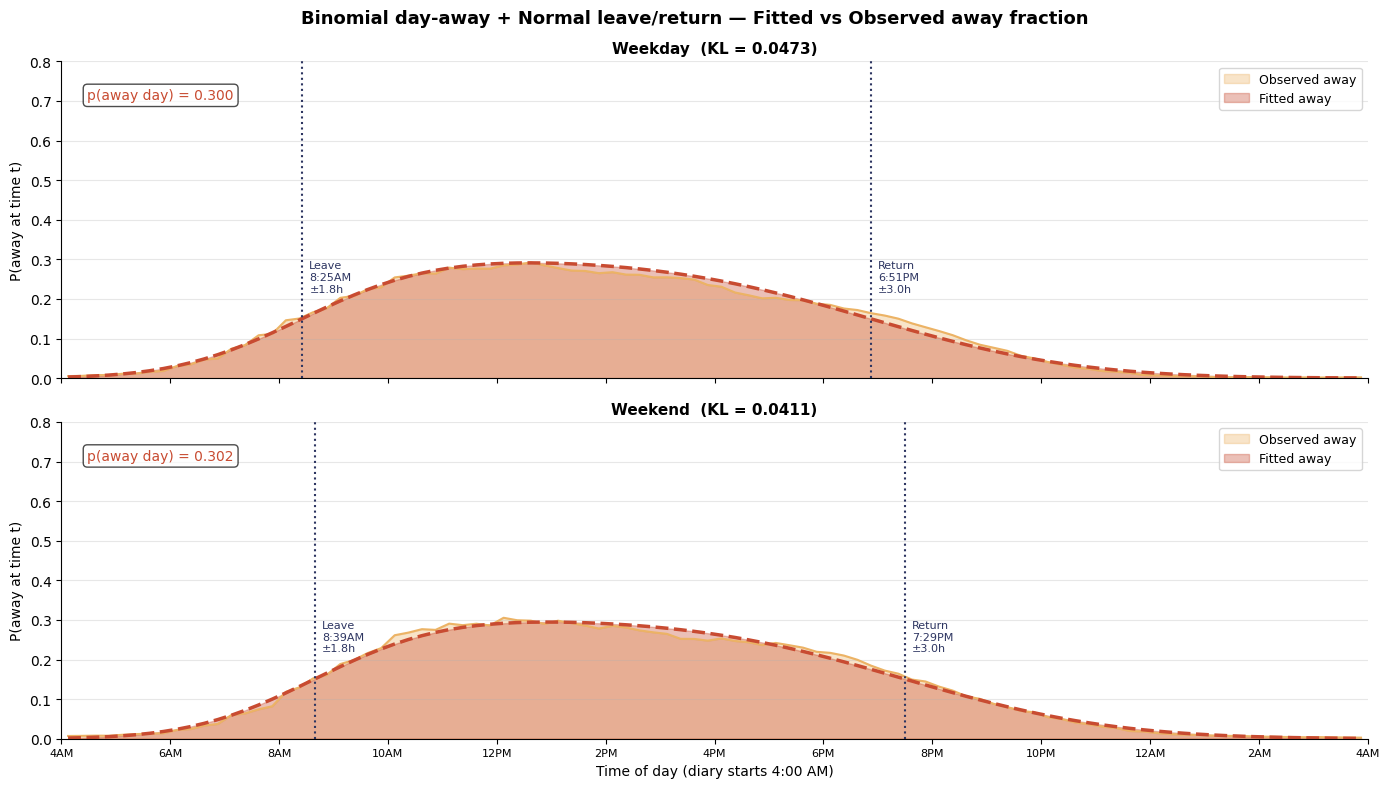

In [181]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle(
    'Binomial day-away + Normal leave/return — Fitted vs Observed away fraction',
    fontsize=13, fontweight='bold'
)

for ax, (label, away_obs, res) in zip(axes, [
    ('Weekday', wd_away_obs, res_wd_bn),
    ('Weekend', we_away_obs, res_we_bn),
]):
    p, mu_l, sig_l, mu_r, sig_r = res.x
    away_pred = model_binom_normal(p, mu_l, sig_l, mu_r, sig_r)

    ax.fill_between(bucket_centers, away_obs,  alpha=0.35, color='#ecb365', label='Observed away')
    ax.fill_between(bucket_centers, away_pred, alpha=0.35, color='#c84b31', label='Fitted away')
    ax.plot(bucket_centers, away_obs,  color='#ecb365', lw=1.5)
    ax.plot(bucket_centers, away_pred, color='#c84b31', lw=2.5, ls='--')

    # Mark leave / return means
    ax.axvline(mu_l, color='#2d3561', lw=1.5, ls=':')
    ax.axvline(mu_r, color='#2d3561', lw=1.5, ls=':')
    ax.text(mu_l + 8, away_pred.max() * 0.75,
            f'Leave\n{fmt(mu_l)}\n±{sig_l/60:.1f}h', fontsize=8, color='#2d3561')
    ax.text(mu_r + 8, away_pred.max() * 0.75,
            f'Return\n{fmt(mu_r)}\n±{sig_r/60:.1f}h', fontsize=8, color='#2d3561')

    # Annotate p
    ax.text(0.02, 0.88,
            f'p(away day) = {p:.3f}',
            transform=ax.transAxes, fontsize=10, color='#c84b31',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    ax.set_ylim(0, min(1, away_pred.max() * 1.5))
    ax.set_ylabel('P(away at time t)', fontsize=10)
    ax.set_title(f'{label}  (KL = {res.fun:.4f})', fontsize=11, fontweight='bold')
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_xlim(0, N_BUCKETS * BUCKET_MINUTES)
    ax.set_ylim(0,0.8)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

axes[-1].set_xlabel('Time of day (diary starts 4:00 AM)', fontsize=10)
plt.tight_layout()
plt.savefig('binom_normal_fit.png', dpi=150, bbox_inches='tight')
plt.show()